# Preprocessing

This notebook runs preprocessing directly by calling `src/preprocessing.py` functions.

In [10]:
from pathlib import Path
from types import SimpleNamespace
import csv
import sys

from IPython.display import display
from PIL import Image

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import config
from preprocessing import preprocess_images
from scale_bar import DEFAULT_FALLBACK_BOTTOM, DEFAULT_FALLBACK_TOP, DEFAULT_NORMALIZE_MAX, DEFAULT_NORMALIZE_MIN, DEFAULT_SCALE_BAR

In [11]:
MAX_IMAGES = None  # Set to None to process all images.

args = SimpleNamespace(
    thermal_dir=config.THERMAL_IMAGES_DIR,
    output_dir=config.PREPROCESSED_IMAGES_DIR,
    temperature_map_dir=config.PREPROCESSED_TEMPERATURE_MAPS_DIR,
    summary_csv=config.PREPROCESSING_SUMMARY_CSV,
    scale_labels_csv=config.SCALE_LABELS_CSV,
    scale_bar=DEFAULT_SCALE_BAR,
    fallback_top=DEFAULT_FALLBACK_TOP,
    fallback_bottom=DEFAULT_FALLBACK_BOTTOM,
    normalize_min=DEFAULT_NORMALIZE_MIN,
    normalize_max=DEFAULT_NORMALIZE_MAX,
    pad_height=640,
    no_rotate_180=False,
    max_images=MAX_IMAGES,
)
args

namespace(thermal_dir=PosixPath('/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/thermal_images'),
          output_dir=PosixPath('/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/preprocessed/images'),
          temperature_map_dir=PosixPath('/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/preprocessed/temperature_maps'),
          summary_csv=PosixPath('/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/preprocessed/preprocessing_summary.csv'),
          scale_labels_csv=PosixPath('/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/used_scale_labels.csv'),
          scale_bar=(618, 47, 633, 431),
          fallback_top=33.1,
          fallback_bottom=19.0,
          normalize_min=18.0,
          normalize_max=50.0,
          pad_height=640,
          no_rotate_180=False,
          max_images=None)

In [8]:
preprocessing_rows = preprocess_images(args)
len(preprocessing_rows), preprocessing_rows[:2]

(9119,
 [{'index': 1,
   'image_name': 'IR_57327.jpg',
   'source_image_path': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/thermal_images/IR_57327.jpg',
   'preprocessed_image_path': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/preprocessed/images/IR_57327.png',
   'temperature_map_path': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/preprocessed/temperature_maps/IR_57327.npy',
   'scale_top': 34.0,
   'scale_bottom': 19.5,
   'scale_source': 'digit_classifier',
   'scale_ocr_score': 0.0,
   'normalize_min': 18.0,
   'normalize_max': 50.0,
   'width': 640,
   'height': 640},
  {'index': 2,
   'image_name': 'IR_57328.jpg',
   'source_image_path': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/thermal_images/IR_57328.jpg',
   'preprocessed_image_path': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/preprocessed/images/IR_57328.png',
   'temperature_map_path': '/Users/pck/TUe_A

IR_57327.jpg


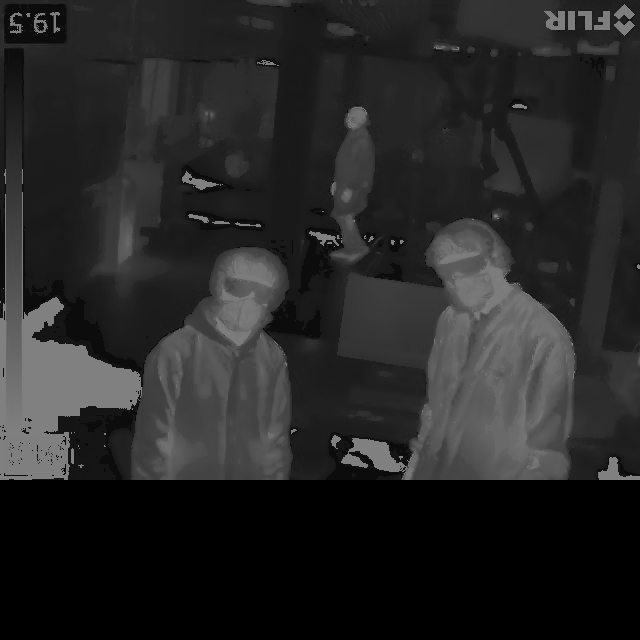

In [9]:
if preprocessing_rows:
    sample = preprocessing_rows[0]
    print(sample['image_name'])
    display(Image.open(sample['preprocessed_image_path']))